In [2]:
import numpy as np
import pandas as pd 
import matplotlib.pyplot as plt
import seaborn as sns

In [3]:
print("hi")

hi


In [4]:
df = pd.read_csv(r"C:/Users/Shubham/Documents/Coding/ML-assignments/ML-assignments/EDA/healthcare-dataset-stroke-data.csv")
df.head()

,id,gender,age,hypertension,heart_disease,ever_married,work_type,Residence_type,avg_glucose_level,bmi,smoking_status,stroke
0,9046,Male,67.0,0,1,Yes,Private,Urban,228.69,36.6,formerly smoked,1
1,51676,Female,61.0,0,0,Yes,Self-employed,Rural,202.21,NaN,never smoked,1
2,31112,Male,80.0,0,1,Yes,Private,Rural,105.92,32.5,never smoked,1
3,60182,Female,49.0,0,0,Yes,Private,Urban,171.23,34.4,smokes,1
4,1665,Female,79.0,1,0,Yes,Self-employed,Rural,174.12,24.0,never smoked,1


In [5]:
df.shape

(5110, 12)

In [6]:
df.columns

Index(['id', 'gender', 'age', 'hypertension', 'heart_disease', 'ever_married',
       'work_type', 'Residence_type', 'avg_glucose_level', 'bmi',
       'smoking_status', 'stroke'],
      dtype='str')

In [7]:
df.dtypes

id                     int64
gender                   str
age                  float64
hypertension           int64
heart_disease          int64
ever_married             str
work_type                str
Residence_type           str
avg_glucose_level    float64
bmi                  float64
smoking_status           str
stroke                 int64
dtype: object

In [8]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 5110 entries, 0 to 5109
Data columns (total 12 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   id                 5110 non-null   int64  
 1   gender             5110 non-null   str    
 2   age                5110 non-null   float64
 3   hypertension       5110 non-null   int64  
 4   heart_disease      5110 non-null   int64  
 5   ever_married       5110 non-null   str    
 6   work_type          5110 non-null   str    
 7   Residence_type     5110 non-null   str    
 8   avg_glucose_level  5110 non-null   float64
 9   bmi                4909 non-null   float64
 10  smoking_status     5110 non-null   str    
 11  stroke             5110 non-null   int64  
dtypes: float64(3), int64(4), str(5)
memory usage: 479.2 KB


In [9]:
df.describe()

,id,age,hypertension,heart_disease,avg_glucose_level,bmi,stroke
count,5110.000000,5110.000000,5110.000000,5110.000000,5110.000000,4909.000000,5110.000000
mean,36517.829354,43.226614,0.097456,0.054012,106.147677,28.893237,0.048728
std,21161.721625,22.612647,0.296607,0.226063,45.283560,7.854067,0.215320
min,67.000000,0.080000,0.000000,0.000000,55.120000,10.300000,0.000000
25%,17741.250000,25.000000,0.000000,0.000000,77.245000,23.500000,0.000000
50%,36932.000000,45.000000,0.000000,0.000000,91.885000,28.100000,0.000000
75%,54682.000000,61.000000,0.000000,0.000000,114.090000,33.100000,0.000000
max,72940.000000,82.000000,1.000000,1.000000,271.740000,97.600000,1.000000


In [10]:
df.isnull().sum()

id                     0
gender                 0
age                    0
hypertension           0
heart_disease          0
ever_married           0
work_type              0
Residence_type         0
avg_glucose_level      0
bmi                  201
smoking_status         0
stroke                 0
dtype: int64

In [11]:
df['bmi'] = pd.to_numeric(df['bmi'], errors='coerce')
df = df.fillna(df['bmi'].mean())
df.head()

,id,gender,age,hypertension,heart_disease,ever_married,work_type,Residence_type,avg_glucose_level,bmi,smoking_status,stroke
0,9046,Male,67.0,0,1,Yes,Private,Urban,228.69,36.600000,formerly smoked,1
1,51676,Female,61.0,0,0,Yes,Self-employed,Rural,202.21,28.893237,never smoked,1
2,31112,Male,80.0,0,1,Yes,Private,Rural,105.92,32.500000,never smoked,1
3,60182,Female,49.0,0,0,Yes,Private,Urban,171.23,34.400000,smokes,1
4,1665,Female,79.0,1,0,Yes,Self-employed,Rural,174.12,24.000000,never smoked,1


In [12]:
df.duplicated().sum()

np.int64(0)

In [13]:
df.nunique()

id                   5110
gender                  3
age                   104
hypertension            2
heart_disease           2
ever_married            2
work_type               5
Residence_type          2
avg_glucose_level    3979
bmi                   419
smoking_status          4
stroke                  2
dtype: int64

In [14]:
for col in ['gender', 'hypertension', 'heart_disease', 'ever_married', 'work_type', 'Residence_type', 'smoking_status', 'stroke']:
    print(f"{col}: {df[col].unique()}")

gender: <StringArray>
['Male', 'Female', 'Other']
Length: 3, dtype: str
hypertension: [0 1]
heart_disease: [1 0]
ever_married: <StringArray>
['Yes', 'No']
Length: 2, dtype: str
work_type: <StringArray>
['Private', 'Self-employed', 'Govt_job', 'children', 'Never_worked']
Length: 5, dtype: str
Residence_type: <StringArray>
['Urban', 'Rural']
Length: 2, dtype: str
smoking_status: <StringArray>
['formerly smoked', 'never smoked', 'smokes', 'Unknown']
Length: 4, dtype: str
stroke: [1 0]


In [15]:
plt.style.use('dark_background')

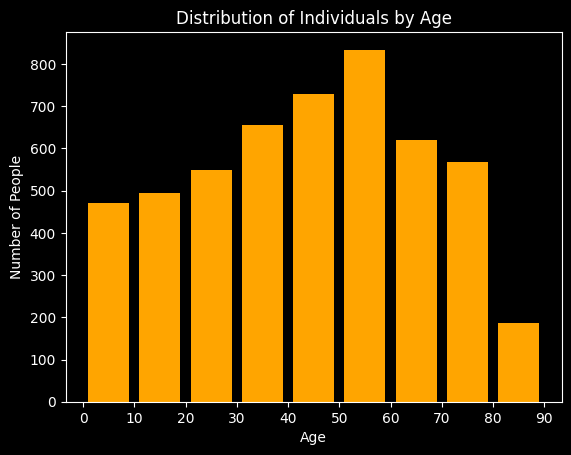

In [56]:
bins = np.arange(0,100,10)
plt.hist(df['age'], bins=bins, color='orange', rwidth= 0.8)
plt.xticks(np.arange(0,100,10))
plt.title("Distribution of Individuals by Age")
plt.xlabel("Age")
plt.ylabel("Number of People")
plt.show()

From the above plot we can observe that the data we have is normaly divided across all age catogries which will help us for data analysis.

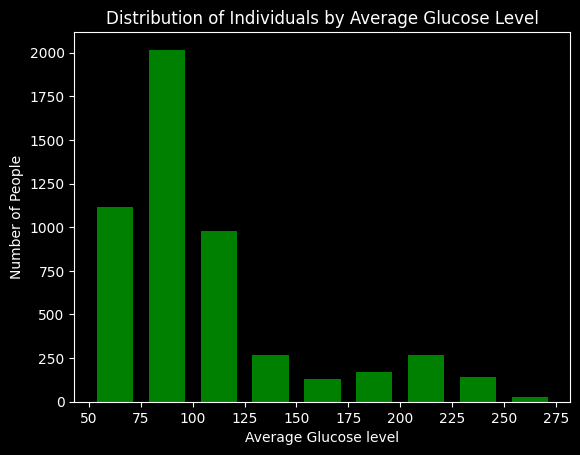

In [57]:
bins = np.arange(50,300,25)
plt.hist(df['avg_glucose_level'], bins=bins, color='green', rwidth= 0.7)
plt.xticks(np.arange(50,300,25))
plt.title("Distribution of Individuals by Average Glucose Level")
plt.xlabel("Average Glucose level")
plt.ylabel("Number of People")
plt.show()

From the above plot we can observe that the average glucose level of the people is on the lower side.

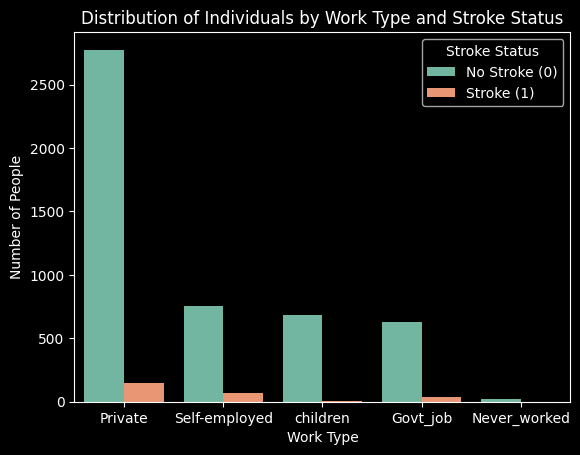

In [48]:
work_type_order = df["work_type"].value_counts().index

sns.countplot(data=df, x="work_type", hue="stroke", order=work_type_order, palette="Set2")
plt.title("Distribution of Individuals by Work Type and Stroke Status")
plt.xlabel("Work Type")
plt.ylabel("Number of People")
plt.legend(title="Stroke Status", labels=["No Stroke (0)", "Stroke (1)"])

From the above plot we can observe that we have most of the data of private sector and private sector employees get more strokes as compared to other.

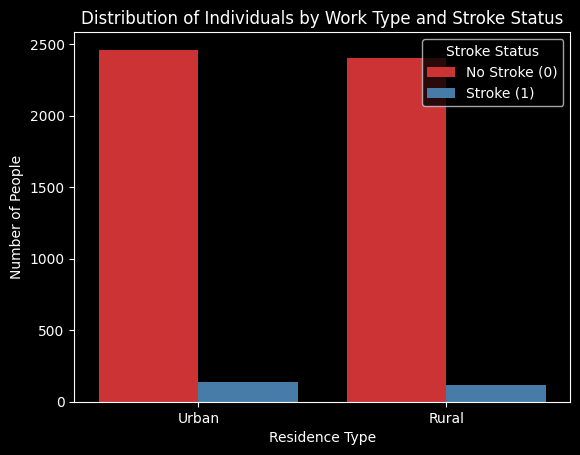

In [49]:
Residence_type_order = df["Residence_type"].value_counts().index

sns.countplot(data=df, x="Residence_type", hue="stroke", order=Residence_type_order, palette="Set1")
plt.title("Distribution of Individuals by Work Type and Stroke Status")
plt.xlabel("Residence Type")
plt.ylabel("Number of People")
plt.legend(title="Stroke Status", labels=["No Stroke (0)", "Stroke (1)"])

From the above plot we can observe that we have approximately equal number of people from rural and urban residence who had or did not have stroke.

C:\Users\Shubham\AppData\Local\Temp\ipykernel_57072\720956454.py:1: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='stroke', y='age', palette='Set2')


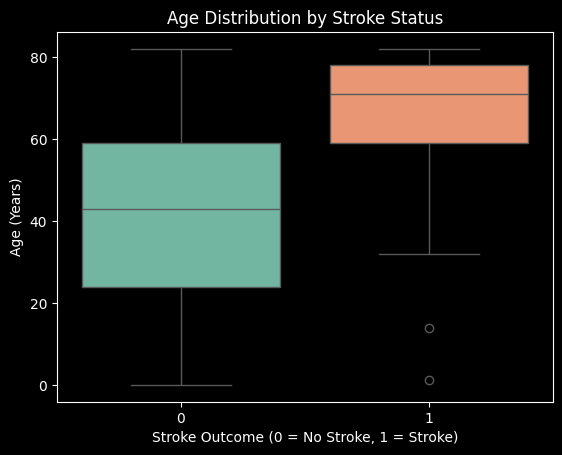

In [63]:
sns.boxplot(data=df, x='stroke', y='age', palette='Set2')
plt.title('Age Distribution by Stroke Status')
plt.xlabel('Stroke Outcome (0 = No Stroke, 1 = Stroke)')
plt.ylabel('Age (Years)')
plt.show()

From the above plot we can observe that we can see that majority people who had stroke was from age range 60 to 80.

<Axes: xlabel='avg_glucose_level', ylabel='age'>

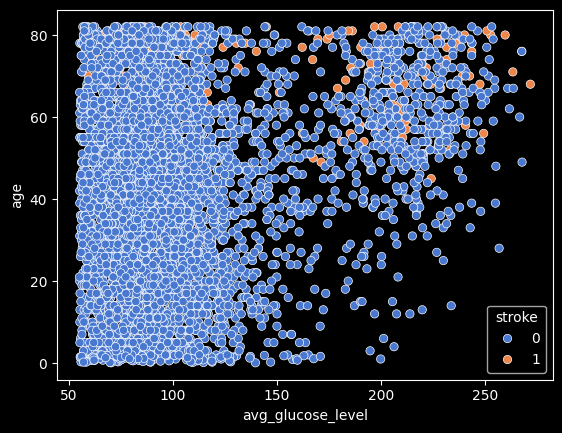

In [26]:
sns.scatterplot(x= 'avg_glucose_level', y='age', data=df, palette='muted', hue='stroke')


From the above plot we can observe that average glucose level of majority of people was less than 125.

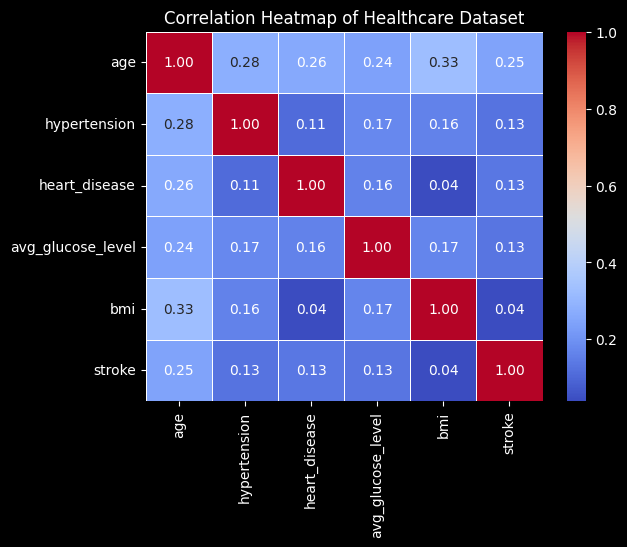

In [27]:
numerical_cols = ["age", "hypertension", "heart_disease", "avg_glucose_level", "bmi", "stroke",]
correlation_matrix = df[numerical_cols].corr()

sns.heatmap(correlation_matrix, annot=True, cmap="coolwarm", fmt=".2f",linewidths=0.5,)
plt.title("Correlation Heatmap of Healthcare Dataset")
plt.show()

From the above plot we can observe that we can see the corelation between the various numerical parameters.

<Axes: xlabel='gender', ylabel='stroke'>

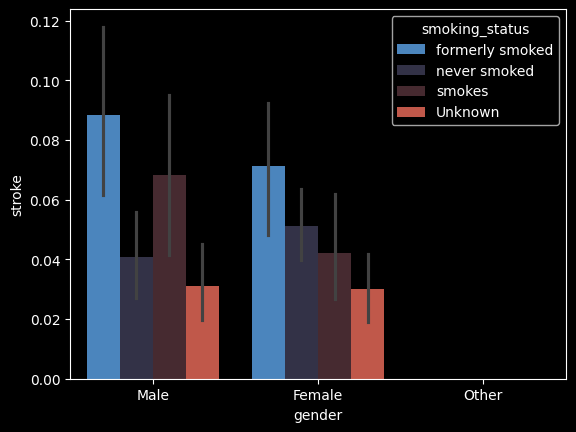

In [54]:
sns.barplot(x = 'gender', y = 'stroke', data =df, hue = 'smoking_status', palette = 'icefire')

From the above plot we can observe that we can see that majority people who got a stroke are who smokes or formerly smoked and generally male are greater in number than female.

Insights/Conclusions:
1. The data has a good mix of all age groups, so it is perfect for analysis.
2. Most people (around 80%) have an average glucose level below 125.
3. More than half of the people in this data work in the private sector.
4. Private workers have the most stroke cases in total, but self-employed people actually have the highest percentage rate of strokes.
5. The number of people from rural and urban areas is almost exactly the same.
6. Living in a city or a village does not change your chances of getting a stroke, as both have almost the same rate.
7. Most of the people who got a stroke (over 63%) were between 60 and 80 years old.
8. People who used to smoke have a higher stroke rate than people who currently smoke or never smoked.
9. Men have a slightly higher percentage chance of getting a stroke compared to women.
10. The plots show that older age links closely with higher BMI, higher glucose, and a much higher risk of stroke.